In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [2]:
def build_star_arms(center=0, num_arms=4, arm_length=3):
    """
    Creates a 'star-like' graph with one center node (center)
    and 'num_arms' arms, each of length 'arm_length'.
    E.g., for arm_length=3, each arm will have 3 nodes in a line from the center.
    """
    G = nx.Graph()
    G.add_node(center)
    next_label = 1  # to label new nodes
    
    # Create arms
    for _ in range(num_arms):
        prev = center
        for _ in range(arm_length):
            G.add_node(next_label)
            G.add_edge(prev, next_label)
            prev = next_label
            next_label += 1
    return G

def def1_receptive_field(G, v, K):
    """
    Definition #1: N^K_v accumulates neighbors in up to K expansions.
    We store them iteratively.
    """
    # start with neighbors of v
    current = set(G[v])  # immediate neighbors
    accum  = set(current)
    
    for _ in range(2, K+1):  # from layer=2 to K
        new_nodes = set()
        for w in current:
            new_nodes.update(G[w])  # neighbors of w
        # union with accum
        accum.update(new_nodes)
        # next iteration
        current = new_nodes
    
    return accum

def def1_receptive_field_list(G, v, K):
    """
    Definition #1: N^K_v accumulates neighbors in up to K expansions, bt using list instead of set.
    We store them iteratively.
    """
    # start with neighbors of v
    current = list(G[v])  # immediate neighbors
    accum  = list(current)
    
    for _ in range(2, K+1):  # from layer=2 to K
        new_nodes = []
        for w in current:
            new_nodes.extend(G[w])  # neighbors of w
        # union with accum
        accum.extend(new_nodes)
        # next iteration
        current = new_nodes
    
    return accum


def def2_bfs_shortest(G, v, K):
    """
    Definition #2: BFS-based. B_r^K(v) are nodes at distance < K from v.
    So we want all nodes whose BFS distance to v is <= (K-1).
    """
    # BFS search up to distance K-1
    visited = set([v])
    frontier = {v}
    dist = 0
    while dist < K:  # once dist == K, we stop
        next_frontier = set()
        for w in frontier:
            for neigh in G[w]:
                if neigh not in visited:
                    visited.add(neigh)
                    next_frontier.add(neigh)
        frontier = next_frontier
        dist += 1
    
    # remove v if you want only others
    visited.discard(v)
    return visited

def adjacency_matrix(G):
    """Convert a NetworkX Graph to a NumPy adjacency matrix 
       (ordered by sorted node IDs)."""
    nodes = sorted(G.nodes())
    idx_map = {node: i for i, node in enumerate(nodes)}
    n = len(nodes)
    A = np.zeros((n, n), dtype=np.float64)
    for u, v in G.edges():
        i, j = idx_map[u], idx_map[v]
        # Assuming undirected
        A[i, j] = 1
        A[j, i] = 1
    return A, nodes

def matrix_kth_power(A, k):
    """Compute A^k (k-th power of adjacency matrix A) using numpy."""
    return np.linalg.matrix_power(A, k)


def aggregator_multiset(A, v, K):
    """
    aggregator_multiset(A, v, K):
      - A: adjacency matrix (n x n)
      - v: node index (0-based) in that matrix
      - K: number of expansions
    Returns a length-n array 'counts' where counts[w] 
    is the sum_{l=1..K} (A^l)[v,w], i.e. how many length-l walks from v to w.
    """
    n = A.shape[0]
    counts = np.zeros(n, dtype=np.float64)
    # For repeated expansions:
    Ak = np.eye(n)  # A^0
    for l in range(1, K+1):
        Ak = Ak @ A   # Now Ak = A^l
        counts += Ak[v,:]
    return counts

In [48]:

# Build Graph
#G = build_star_arms(center=0, num_arms=3, arm_length=3) #STAR
G = nx.stochastic_block_model([20, 20], [[0.6, 0.02], [0.02, 0.6]]) #SBM
G = nx.powerlaw_cluster_graph(100, 3, 0.1) #POWERLAW
A, nodes = adjacency_matrix(G)
K=10

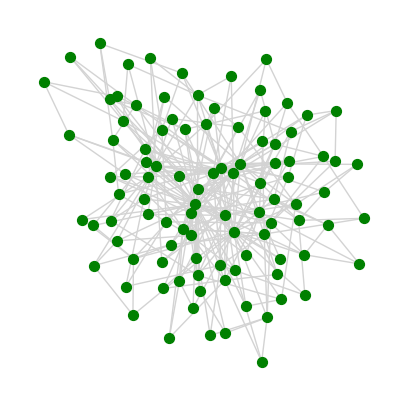

In [57]:
# Plot the graph
plt.figure(figsize=(5,5))
pos = nx.spring_layout(G, seed=42)  # A layout for visualization
nx.draw_networkx(
    G, pos=pos, with_labels=False, node_size=50, node_color="green", edge_color="lightgray",
)
plt.axis("off")
plt.show()

In [58]:
def print_node_receptive_field(G,v,K):
    r1 = def1_receptive_field(G, v, K)
    r1_list = def1_receptive_field_list(G, v, K)
    r2 = def2_bfs_shortest(G, v, K)
    counts_up_toK = aggregator_multiset(A, v, K)
    print(f"Node {v}:")
    print(f"\tCounts from node {nodes[v]} up to length {K} -> {sum(counts_up_toK)}")
    print(f"\tDef#1 (Alon)  -> {len(sorted(r1))}")
    print(f"\tDef#1L (Alon if multisets) -> {len(sorted(r1_list))}")
    print(f"\tDef#2  (Topping) -> {len(sorted(r2))}")
    print()

In [59]:
print_node_receptive_field(G,0,3)

Node 0:
	Counts from node 0 up to length 3 -> 1579.0
	Def#1 (Alon)  -> 100
	Def#1L (Alon if multisets) -> 1579
	Def#2  (Topping) -> 99



In [60]:
#for v in G.nodes():
#    print_node_receptive_field(G,v,K)

**Plot evolution of receptive field vs Computational bottleneck**

In [61]:
K=6
receptive_field1_per_k = np.zeros((K,G.number_of_nodes()))
receptive_field2_per_k = np.zeros((K,G.number_of_nodes()))

In [62]:
for v in sorted(G.nodes()):
    for k_it in range(1,K+1):
        r1 = def1_receptive_field(G, v, k_it)
        counts_up_toK = aggregator_multiset(A, v, k_it)

        receptive_field1_per_k[k_it-1,v] = len(sorted(r1))
        receptive_field2_per_k[k_it-1,v] = sum(counts_up_toK)


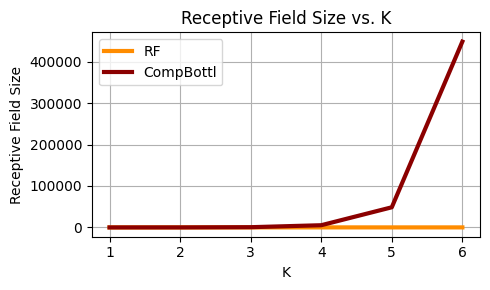

In [73]:
f, ax = plt.subplots(1, 1, figsize=(5, 3))
plt.title("Receptive Field Size vs. K")
plt.xlabel("K")
plt.ylabel("Receptive Field Size")
plt.grid()
plt.plot(np.arange(1,K+1,1), receptive_field1_per_k.mean(axis=1), label="RF", linewidth=3, color='darkorange')
plt.plot(np.arange(1,K+1,1), receptive_field2_per_k.mean(axis=1), label="CompBottl", linewidth=3, color='darkred')
#plt.plot(np.arange(1,K+1,1), receptive_field1_per_k,  linewidth=1, color='darkorange', alpha=0.05)
#plt.plot(np.arange(1,K+1,1), receptive_field2_per_k,  linewidth=1, color='darkred', alpha=0.05)
plt.legend()
plt.tight_layout()
plt.show()

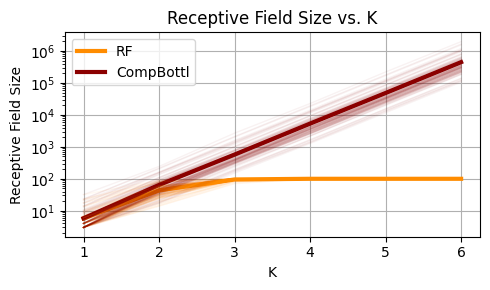

In [74]:
f, ax = plt.subplots(1, 1, figsize=(5, 3))
plt.title("Receptive Field Size vs. K")
plt.xlabel("K")
plt.ylabel("Receptive Field Size")
plt.grid()
plt.plot(np.arange(1,K+1,1), receptive_field1_per_k.mean(axis=1), label="RF", linewidth=3, color='darkorange')
plt.plot(np.arange(1,K+1,1), receptive_field2_per_k.mean(axis=1), label="CompBottl", linewidth=3, color='darkred')
plt.plot(np.arange(1,K+1,1), receptive_field1_per_k,  linewidth=1, color='darkorange', alpha=0.05)
plt.plot(np.arange(1,K+1,1), receptive_field2_per_k,  linewidth=1, color='darkred', alpha=0.05)
plt.legend()
plt.yscale('log')
plt.tight_layout()
plt.show()